In [1]:
import numpy as np
import matplotlib.pyplot as plt
import microscopy_data_analysis as mda

In [2]:
example_path="test_stitching/"
pathlist=mda.get_files_of_format(example_path,"tif")
N=len(pathlist)
pathlist

['test_stitching/image_00.tif',
 'test_stitching/image_01.tif',
 'test_stitching/image_02.tif',
 'test_stitching/image_03.tif',
 'test_stitching/image_04.tif',
 'test_stitching/image_05.tif',
 'test_stitching/image_06.tif',
 'test_stitching/image_07.tif',
 'test_stitching/image_08.tif',
 'test_stitching/image_09.tif',
 'test_stitching/image_10.tif',
 'test_stitching/image_11.tif',
 'test_stitching/image_12.tif',
 'test_stitching/image_13.tif',
 'test_stitching/image_14.tif',
 'test_stitching/image_15.tif',
 'test_stitching/image_16.tif',
 'test_stitching/image_17.tif',
 'test_stitching/image_18.tif',
 'test_stitching/image_19.tif',
 'test_stitching/image_20.tif',
 'test_stitching/image_21.tif',
 'test_stitching/image_22.tif',
 'test_stitching/image_23.tif',
 'test_stitching/image_24.tif']

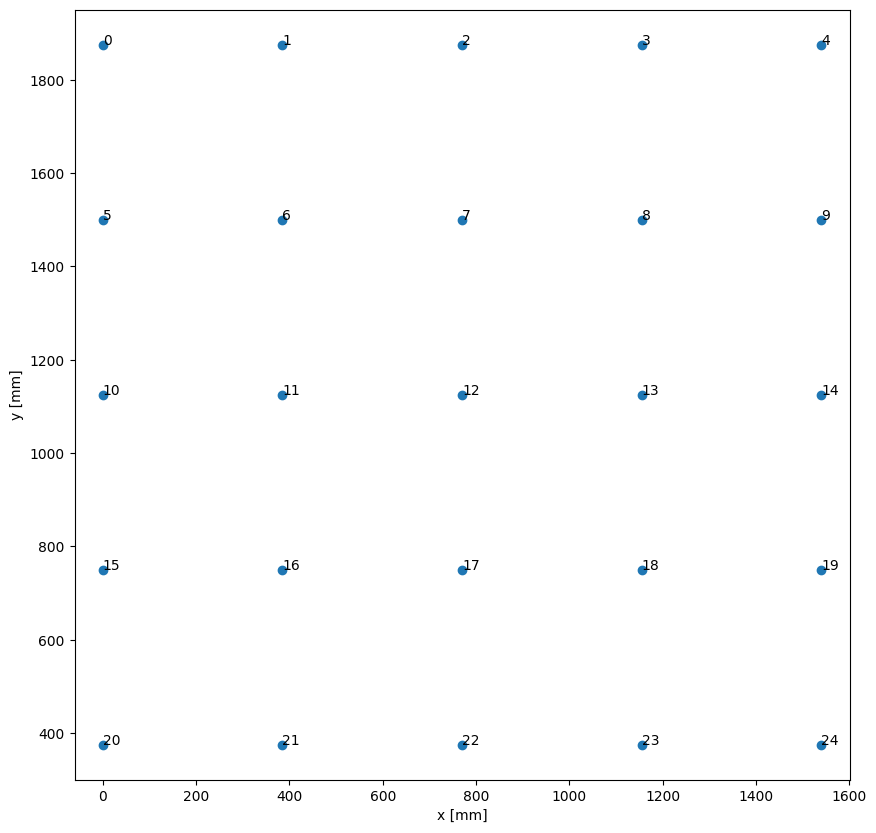

In [3]:
%matplotlib inline
positions=np.zeros([N,2])
counter=0
for i in range(5):
    for j in range(5):
        if counter==len(positions):
            break
        positions[counter]=j*385,5*375-i*375
        counter+=1

plt.figure(figsize=[10,10])
plt.plot(positions[:,0],positions[:,1],'o')
for i in range(len(positions)):
    plt.text(positions[i,0],positions[i,1],str(i))
plt.xlabel(r"x [mm]")
plt.ylabel(r"y [mm]")
plt.axis("equal")
plt.show()

In [4]:
# needed:
#pathlist,positions

In [ ]:
stitch_object=mda.stitching_object(mode='storage')
stitch_object.set_img_list(pathlist[:])

For .h5 provide the path to the h5-file (that serves as h5-directory) via the 'set_directory_path' method
For .tif, .png, ... image files either provide the folder via 'set_directory_path' or a list of filepaths via 'set_img_list'


In [6]:
stitch_object.sniff_dimensions()

In [7]:
stitch_object.set_units_per_pixel(1.1)

In [8]:
stitch_object.set_positions(positions[:])
polygons,anchor_points=stitch_object.make_polygons(orientation=2)

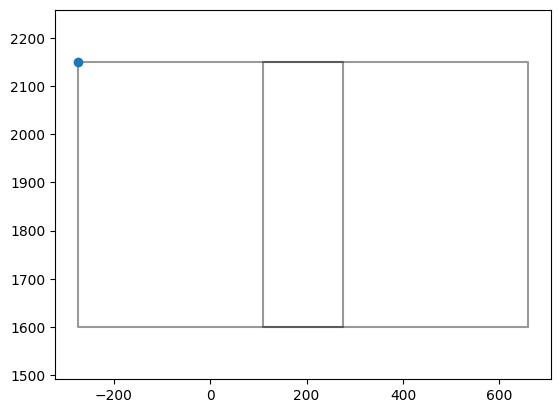

In [9]:
%matplotlib inline

#check for two images, if there is overlap

index=0
plt.plot(np.array(polygons[index].exterior.xy[0]),np.array(polygons[index].exterior.xy[1]),'k-',alpha=0.4)
plt.plot(anchor_points[index][0],anchor_points[index][1],'o')
index=1
plt.plot(np.array(polygons[index].exterior.xy[0]),np.array(polygons[index].exterior.xy[1]),'k-',alpha=0.4)
plt.axis("equal")
plt.show()

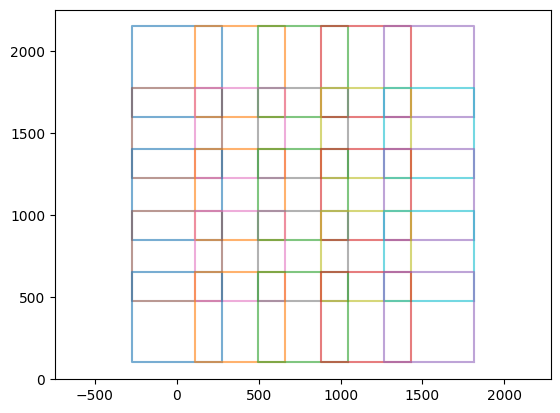

In [10]:
# show all images (abstracted as polygons)
for index in range(len(stitch_object.polygons)):
    plt.plot(np.array(stitch_object.polygons[index].exterior.xy[0]),np.array(stitch_object.polygons[index].exterior.xy[1]),'-',alpha=0.6)
plt.axis("equal")
plt.show()

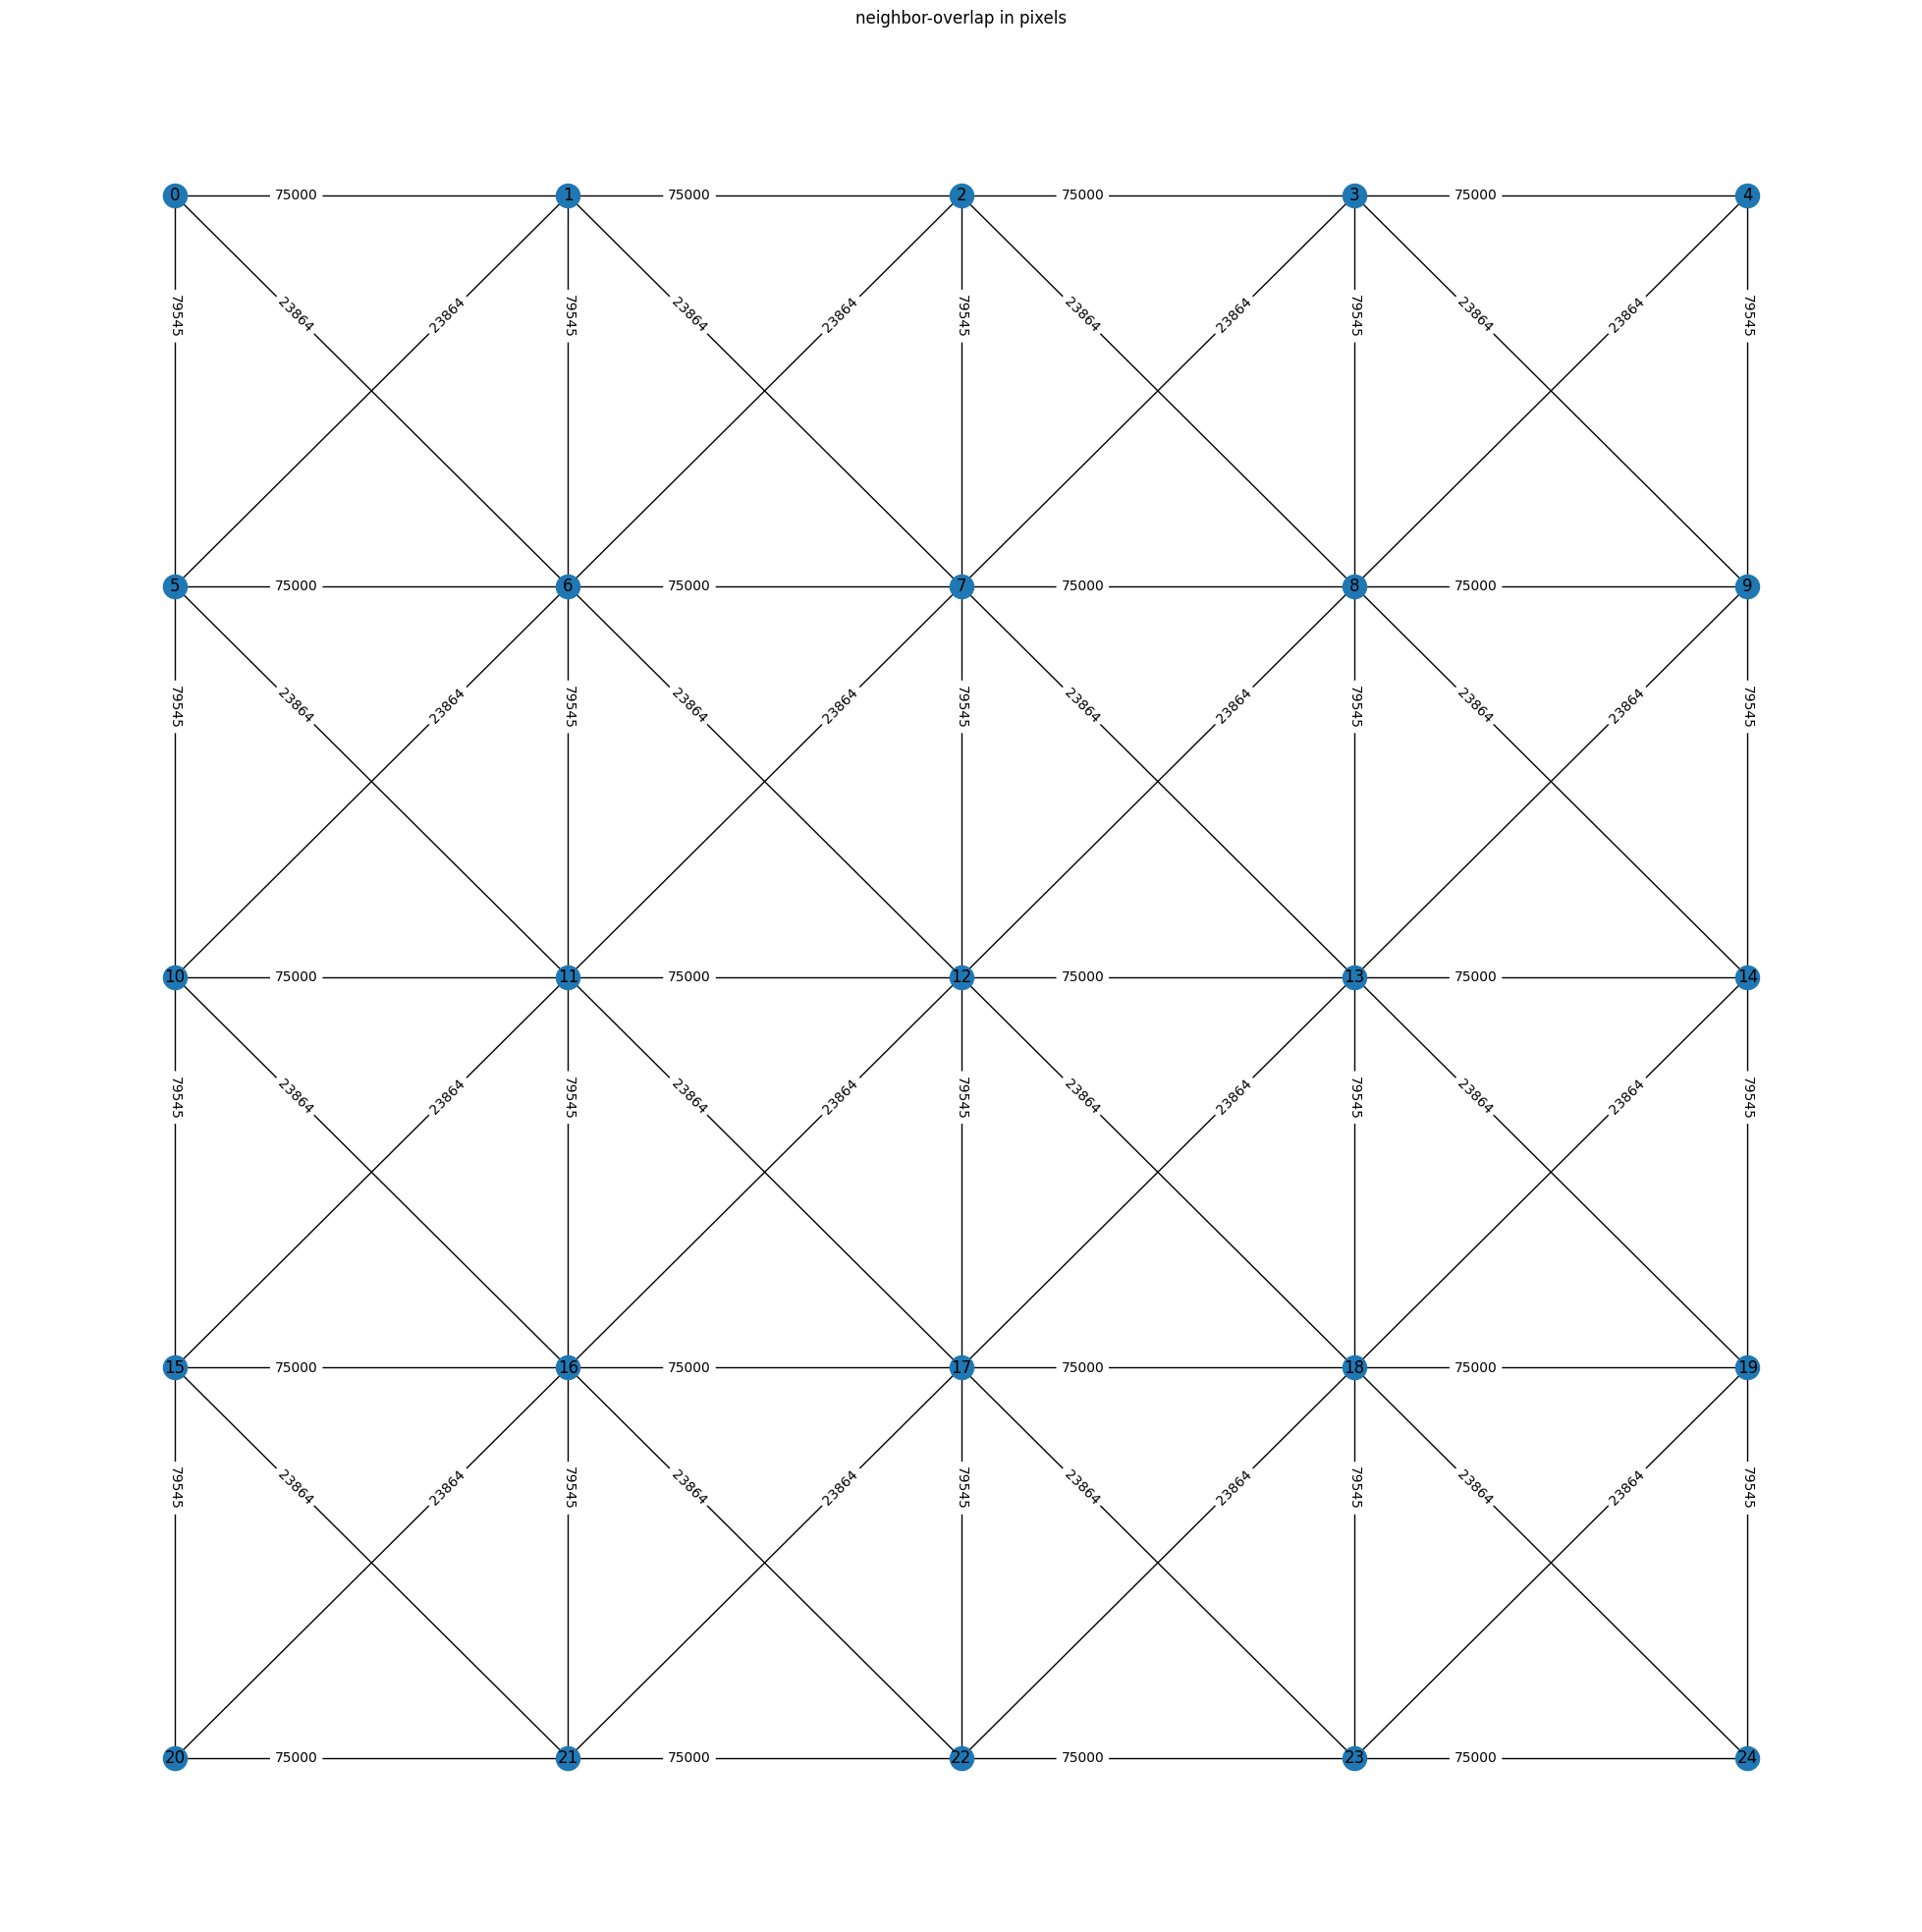

In [11]:
G,con=stitch_object.connection_groups()
stitch_object.plot_connection_network(figsize=[25,25],relative=False)

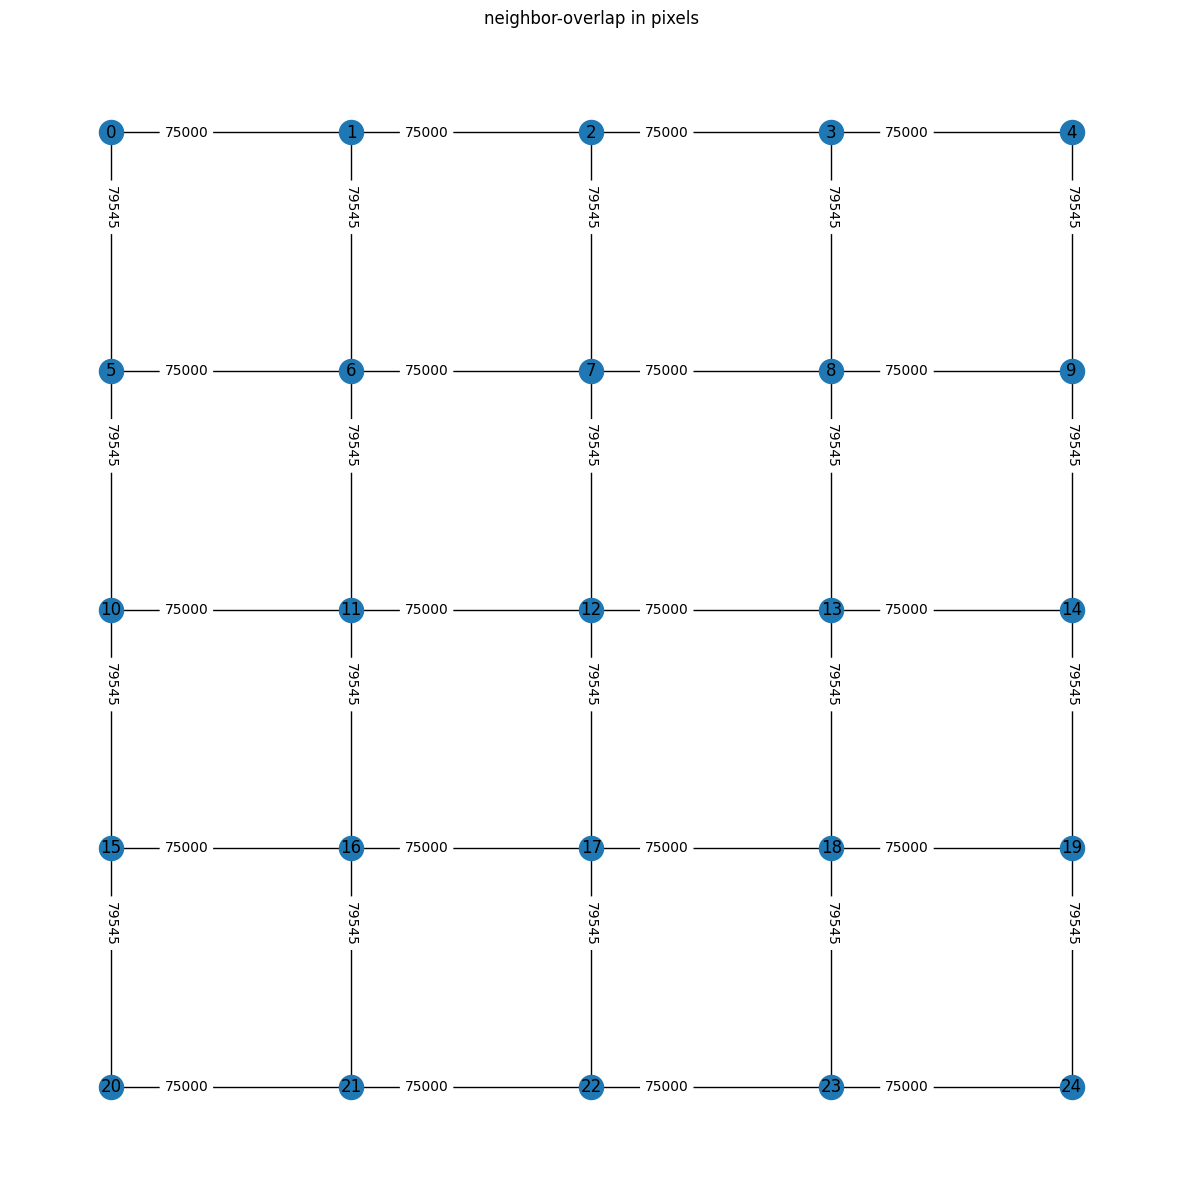

In [12]:
G,con=stitch_object.connection_groups(minimal_number_of_pixels=50000)
stitch_object.plot_connection_network(figsize=[15,15],relative=False)

In [13]:
pair_shifts=stitch_object.check_pairs()

In [14]:
moved_polygons=stitch_object.optimize_positions()

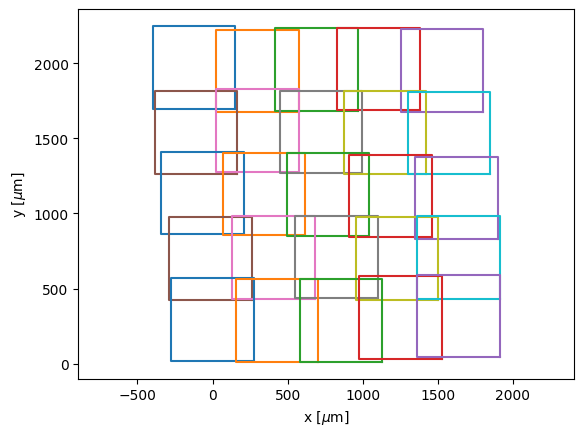

In [15]:
%matplotlib inline
for i in range(len(moved_polygons)):
    plt.plot(np.array(moved_polygons[i].exterior.xy[0]),np.array(moved_polygons[i].exterior.xy[1]))#'k-')
plt.xlabel(r"x [$\mu$m]")
plt.ylabel(r"y [$\mu$m]")
plt.axis("equal")
plt.show()

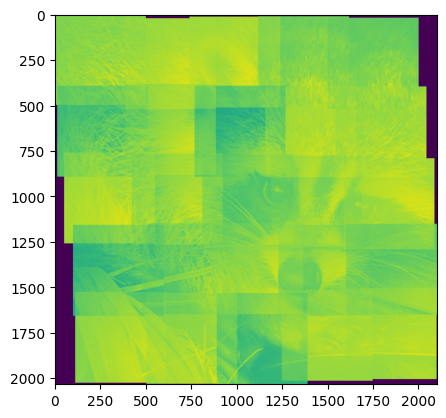

In [16]:
testmap=stitch_object.map_from_polygons(moved_polygons)
plt.imshow(testmap)
plt.show()

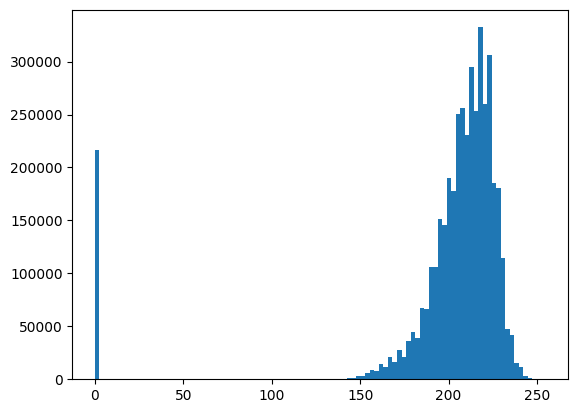

In [17]:
mflat=np.reshape(testmap,testmap.shape[0]*testmap.shape[1])
plt.hist(mflat,100)
plt.show()

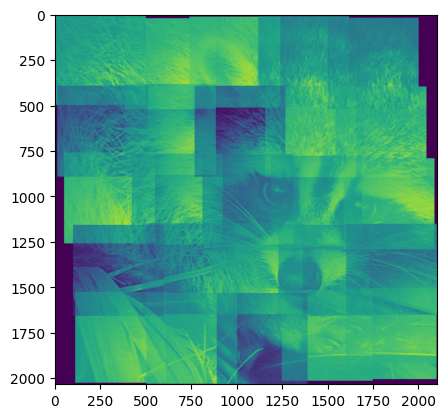

In [18]:
testmap_brightness_adjusted=np.clip(testmap,150,255)
testmap_brightness_adjusted=mda.img_to_uint8(testmap_brightness_adjusted)
plt.imshow(testmap_brightness_adjusted)
plt.show()

In [19]:
mda.imsave("stitching_testmap.png",testmap_brightness_adjusted)

(2034, 2102)


True